# Challenge 2 — Pauli Feature Map con `pytket` desde cero

Este notebook construye una ejecución **nueva, independiente y reproducible** cuyo único input es
`water_potability.csv`.

La implementación no utiliza Qiskit. El equivalente de `PauliFeatureMap` se construye explícitamente
con `pytket.circuit.PauliExpBox`, de modo que cada término aplica

\[
\exp\!\left(i\,\phi_S(x)\,P_S\right),
\qquad P_S \in \{I,X,Y,Z\}^{\otimes n}.
\]

Como `PauliExpBox(P,t)` representa
\(\exp(-i\pi tP/2)\), el notebook usa \(t=-2\phi_S(x)/\pi\).

## Decisiones metodológicas

1. Se crea un **holdout final bloqueado** antes de cualquier análisis.
2. La selección de variables usa un pool independiente y estabilidad por permutación.
3. Se fijan **5 variables = 5 qubits = 32 amplitudes**, evitando los 512 estados de 9 qubits.
4. Las muestras cuánticas proceden de un tercer pool y no contienen datos sintéticos.
5. Imputación y escalado se ajustan dentro de cada fold, incluso durante la búsqueda interna de `C`.
6. Se compara el kernel cuántico con un SVM RBF clásico usando exactamente las mismas filas y folds.
7. Se estudian términos de Pauli, topología, repeticiones, escalado y centrado del kernel.
8. Todos los splits, configuraciones, hashes, kernels, predicciones y métricas se guardan desde cero.

El kernel de fidelidad es

\[
K_{ij}=\left|\langle\phi(x_i)\mid\phi(x_j)\rangle\right|^2
\]

y se entrega a `SVC(kernel="precomputed")`.


In [1]:
# Instalación reproducible para Google Colab.
%pip install -q "pytket==2.18.1" "scikit-learn==1.6.1" "pandas==2.2.3" "matplotlib>=3.9,<4"


     ━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━ 89.9/89.9 kB 2.7 MB/s eta 0:00:00
   ━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━ 8.3/8.3 MB 53.2 MB/s eta 0:00:00
   ━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━ 12.7/12.7 MB 45.4 MB/s eta 0:00:00
ERROR: pip's dependency resolver does not currently take into account all the packages that are installed. This behaviour is the source of the following dependency conflicts.
google-colab 1.0.0 requires pandas==2.2.2, but you have pandas 2.2.3 which is incompatible.


In [2]:
from __future__ import annotations

import hashlib
import json
import math
import os
import shutil
import sys
import time
from dataclasses import asdict, dataclass
from pathlib import Path
from typing import Iterable, Sequence

import matplotlib.pyplot as plt
import numpy as np
import pandas as pd

from IPython.display import HTML, display
from sklearn.ensemble import ExtraTreesClassifier
from sklearn.impute import SimpleImputer
from sklearn.inspection import permutation_importance
from sklearn.metrics import (
    accuracy_score,
    balanced_accuracy_score,
    confusion_matrix,
    f1_score,
    matthews_corrcoef,
    precision_score,
    recall_score,
)
from sklearn.model_selection import RepeatedStratifiedKFold, StratifiedKFold, train_test_split
from sklearn.pipeline import Pipeline
from sklearn.preprocessing import StandardScaler
from sklearn.svm import SVC

import pytket
from pytket import Circuit
from pytket.circuit import CXConfigType, OpType, PauliExpBox
from pytket.circuit.display import render_circuit_as_html, render_circuit_jupyter
from pytket.pauli import Pauli
from pytket.passes import DecomposeBoxes
from pytket.qasm import circuit_to_qasm_str

print("Python:", sys.version)
print("pytket:", pytket.__version__)
assert pytket.__version__ == "2.18.1"
assert not any(name.startswith("qiskit") for name in sys.modules)


Python: 3.12.13 (main, Mar  4 2026, 09:23:07) [GCC 11.4.0]
pytket: 2.18.1


## 1. Configuración congelada

La carpeta de esta versión se limpia al comenzar. El notebook no busca ni carga artefactos de V05, V06 o V07.


In [3]:
SEED_SPLIT = 20260801
SEED_SELECTOR_SPLIT = 20260802
SEED_FEATURE_CV = 20260803
SEED_FEATURE_AUDIT = 20260804
SEED_QUANTUM_SAMPLE = 20260805
SEED_OUTER_FOLDS = 20260806
SEED_INNER_FOLDS = 20260807
SEED_SHOTS = 20260808

TARGET = "Potability"
N_QUBITS = 5
QUANTUM_ROWS = 80
N_OUTER_FOLDS = 5
N_INNER_FOLDS = 3
RESET_ARTIFACTS = True

DATASET_CANDIDATES = [
    # Preferir Drive para que los artefactos persistan y aparezcan en la carpeta creada.
    Path("/content/drive/MyDrive/Colab Notebooks/water_potability.csv"),
    Path("/content/water_potability.csv"),
]

IN_COLAB = "google.colab" in sys.modules
if IN_COLAB:
    from google.colab import drive
    drive.mount("/content/drive")

DATASET_PATH = next((p for p in DATASET_CANDIDATES if p.exists()), None)
if DATASET_PATH is None:
    raise FileNotFoundError(
        "No se encontró water_potability.csv. Colóquelo en /content o "
        "/content/drive/MyDrive/Colab Notebooks/."
    )

ARTIFACT_DIR = DATASET_PATH.parent / "artifacts_pytket_pauli_from_scratch_v1"
ARTIFACT_DIR.mkdir(parents=True, exist_ok=True)
if RESET_ARTIFACTS:
    for child in ARTIFACT_DIR.iterdir():
        shutil.rmtree(child) if child.is_dir() else child.unlink()

print("Único input:", DATASET_PATH)
print("Artefactos:", ARTIFACT_DIR)


Mounted at /content/drive
Único input: /content/drive/MyDrive/Colab Notebooks/water_potability.csv
Artefactos: /content/drive/MyDrive/Colab Notebooks/artifacts_pytket_pauli_from_scratch_v1


In [4]:
def sha256_file(path: Path) -> str:
    h = hashlib.sha256()
    with path.open("rb") as f:
        for chunk in iter(lambda: f.read(1024 * 1024), b""):
            h.update(chunk)
    return h.hexdigest()


def sha256_json(obj: object) -> str:
    payload = json.dumps(obj, sort_keys=True, ensure_ascii=False, default=str).encode()
    return hashlib.sha256(payload).hexdigest()


def write_json(path: Path, obj: object) -> Path:
    path.write_text(
        json.dumps(obj, indent=2, ensure_ascii=False, default=str),
        encoding="utf-8",
    )
    return path


def save_csv(frame: pd.DataFrame, name: str) -> Path:
    path = ARTIFACT_DIR / name
    frame.to_csv(path, index=False)
    return path


def file_record(path: Path) -> dict:
    return {"file": path.name, "sha256": sha256_file(path), "bytes": path.stat().st_size}


def classification_metrics(y_true: np.ndarray, y_pred: np.ndarray) -> dict:
    tn, fp, fn, tp = confusion_matrix(y_true, y_pred, labels=[0, 1]).ravel()
    specificity = tn / (tn + fp) if tn + fp else np.nan
    return {
        "accuracy": accuracy_score(y_true, y_pred),
        "balanced_accuracy": balanced_accuracy_score(y_true, y_pred),
        "precision": precision_score(y_true, y_pred, zero_division=0),
        "recall": recall_score(y_true, y_pred, zero_division=0),
        "specificity": specificity,
        "f1": f1_score(y_true, y_pred, zero_division=0),
        "mcc": matthews_corrcoef(y_true, y_pred),
        "tn": int(tn), "fp": int(fp), "fn": int(fn), "tp": int(tp),
    }


def effective_rank(K: np.ndarray, eps: float = 1e-12) -> float:
    eig = np.linalg.eigvalsh((K + K.T) / 2)
    eig = np.clip(eig, 0, None)
    if eig.sum() <= eps:
        return 0.0
    p = eig / eig.sum()
    return float(np.exp(-np.sum(p[p > eps] * np.log(p[p > eps]))))


def kernel_alignment(K: np.ndarray, y: np.ndarray, eps: float = 1e-12) -> float:
    y_pm = 2 * np.asarray(y, dtype=float) - 1
    T = np.outer(y_pm, y_pm)
    denom = np.linalg.norm(K, "fro") * np.linalg.norm(T, "fro")
    return float(np.sum(K * T) / max(denom, eps))


def kernel_geometry(K: np.ndarray, y: np.ndarray) -> dict:
    y = np.asarray(y)
    same = y[:, None] == y[None, :]
    offdiag = ~np.eye(len(y), dtype=bool)
    intra = K[same & offdiag]
    inter = K[(~same) & offdiag]
    eig = np.linalg.eigvalsh((K + K.T) / 2)
    return {
        "alignment": kernel_alignment(K, y),
        "intra_mean": float(intra.mean()),
        "inter_mean": float(inter.mean()),
        "intra_minus_inter": float(intra.mean() - inter.mean()),
        "effective_rank": effective_rank(K),
        "min_eigenvalue": float(eig.min()),
        "max_eigenvalue": float(eig.max()),
    }


## 2. Dataset, snapshot y tres particiones independientes

- **Selector pool (60%)**: únicamente selección estable de variables.
- **Quantum candidate pool (20%)**: fuente de las observaciones para el kernel.
- **Locked holdout (20%)**: evaluación final, abierta una sola vez al final.


In [5]:
dataset_hash = sha256_file(DATASET_PATH)
SNAPSHOT_PATH = ARTIFACT_DIR / "water_potability_input_snapshot.csv"
shutil.copy2(DATASET_PATH, SNAPSHOT_PATH)
assert sha256_file(SNAPSHOT_PATH) == dataset_hash

df = pd.read_csv(SNAPSHOT_PATH).reset_index(names="source_index")
EXPECTED_COLUMNS = [
    "ph", "Hardness", "Solids", "Chloramines", "Sulfate",
    "Conductivity", "Organic_carbon", "Trihalomethanes",
    "Turbidity", "Potability",
]
assert [c for c in df.columns if c != "source_index"] == EXPECTED_COLUMNS
assert len(df) == 3276
assert set(df[TARGET].unique()) == {0, 1}
FEATURES_ALL = [c for c in EXPECTED_COLUMNS if c != TARGET]

all_idx = np.arange(len(df))
y_all = df[TARGET].to_numpy(dtype=int)

dev_idx, holdout_idx = train_test_split(
    all_idx,
    test_size=0.20,
    random_state=SEED_SPLIT,
    stratify=y_all,
)
selector_idx, candidate_idx = train_test_split(
    dev_idx,
    test_size=0.25,
    random_state=SEED_SELECTOR_SPLIT,
    stratify=y_all[dev_idx],
)

sets = [set(selector_idx), set(candidate_idx), set(holdout_idx)]
assert not (sets[0] & sets[1] or sets[0] & sets[2] or sets[1] & sets[2])
assert sum(map(len, sets)) == len(df)

roles = pd.DataFrame({"source_index": df["source_index"], "role": ""})
roles.loc[selector_idx, "role"] = "selector_pool"
roles.loc[candidate_idx, "role"] = "quantum_candidate_pool"
roles.loc[holdout_idx, "role"] = "locked_holdout"
assert (roles["role"] != "").all()

save_csv(df.iloc[selector_idx].sort_values("source_index"), "selector_pool_raw.csv")
save_csv(df.iloc[candidate_idx].sort_values("source_index"), "quantum_candidate_pool_raw.csv")
save_csv(df.iloc[holdout_idx].sort_values("source_index"), "locked_holdout_raw.csv")
save_csv(roles.sort_values("source_index"), "split_assignments.csv")

split_summary = (
    roles.merge(df[["source_index", TARGET]], on="source_index")
    .groupby(["role", TARGET]).size().rename("count").reset_index()
)
display(split_summary)


,role,Potability,count
0,locked_holdout,0,400
1,locked_holdout,1,256
2,quantum_candidate_pool,0,400
3,quantum_candidate_pool,1,255
4,selector_pool,0,1198
5,selector_pool,1,767


## 3. Selección estable de cinco variables

En lugar de tomar una única importancia por impureza o forzar una variable, se usa:

1. validación estratificada de 5 folds dentro del selector pool;
2. imputación ajustada solo en cada training fold;
3. `ExtraTreesClassifier`;
4. importancia por permutación en el validation fold;
5. ranking por frecuencia en el top-5 y ganancia media de exactitud balanceada.

Las etiquetas del subconjunto cuántico y del holdout no participan.


In [6]:
selector_df = df.iloc[selector_idx].reset_index(drop=True)
X_selector = selector_df[FEATURES_ALL]
y_selector = selector_df[TARGET].to_numpy(dtype=int)

feature_cv = StratifiedKFold(
    n_splits=5, shuffle=True, random_state=SEED_FEATURE_CV
)
feature_fold_rows = []

for fold, (tr, va) in enumerate(feature_cv.split(X_selector, y_selector)):
    imp = SimpleImputer(strategy="median")
    X_tr = imp.fit_transform(X_selector.iloc[tr])
    X_va = imp.transform(X_selector.iloc[va])

    model = ExtraTreesClassifier(
        n_estimators=500,
        min_samples_leaf=2,
        class_weight="balanced",
        random_state=SEED_FEATURE_CV + fold,
        n_jobs=-1,
    )
    model.fit(X_tr, y_selector[tr])

    perm = permutation_importance(
        model,
        X_va,
        y_selector[va],
        scoring="balanced_accuracy",
        n_repeats=15,
        random_state=SEED_FEATURE_CV + 100 + fold,
        n_jobs=-1,
    )
    top5_idx = set(np.argsort(-perm.importances_mean)[:N_QUBITS])

    for j, feature in enumerate(FEATURES_ALL):
        feature_fold_rows.append({
            "fold": fold,
            "feature": feature,
            "permutation_mean": perm.importances_mean[j],
            "permutation_std": perm.importances_std[j],
            "impurity_importance": model.feature_importances_[j],
            "selected_top5": int(j in top5_idx),
        })

feature_fold_df = pd.DataFrame(feature_fold_rows)
feature_summary = (
    feature_fold_df.groupby("feature")
    .agg(
        top5_frequency=("selected_top5", "mean"),
        permutation_mean=("permutation_mean", "mean"),
        permutation_std_across_folds=("permutation_mean", "std"),
        impurity_mean=("impurity_importance", "mean"),
    )
    .reset_index()
    .sort_values(
        ["top5_frequency", "permutation_mean", "impurity_mean"],
        ascending=False,
    )
    .reset_index(drop=True)
)

SELECTED_FEATURES = feature_summary.head(N_QUBITS)["feature"].tolist()
assert len(SELECTED_FEATURES) == N_QUBITS
assert "Conductivity" not in SELECTED_FEATURES or (
    feature_summary.set_index("feature").loc["Conductivity", "top5_frequency"] > 0
)

save_csv(feature_fold_df, "feature_stability_folds.csv")
save_csv(feature_summary, "feature_stability_summary.csv")
write_json(
    ARTIFACT_DIR / "selected_features.json",
    {
        "method": "5-fold held-out permutation importance with ExtraTrees",
        "trained_only_on": "selector_pool",
        "n_qubits": N_QUBITS,
        "selected_features": SELECTED_FEATURES,
        "ranking": feature_summary.to_dict(orient="records"),
    },
)

print("Variables congeladas:", SELECTED_FEATURES)
display(feature_summary)


Variables congeladas: ['Sulfate', 'ph', 'Solids', 'Chloramines', 'Hardness']


,feature,top5_frequency,permutation_mean,permutation_std_across_folds,impurity_mean
0,Sulfate,1.0,0.054100,0.030632,0.127246
1,ph,1.0,0.044615,0.015936,0.127237
2,Solids,1.0,0.032013,0.013983,0.118028
3,Chloramines,1.0,0.027473,0.003970,0.115271
4,Hardness,1.0,0.022855,0.014263,0.115029
5,Trihalomethanes,0.0,0.006690,0.008737,0.099648
6,Conductivity,0.0,0.005899,0.009588,0.103850
7,Turbidity,0.0,0.003805,0.014746,0.096292
8,Organic_carbon,0.0,-0.002940,0.005077,0.097400


### Auditoría de la cantidad de variables

Esta auditoría es clásica y se ejecuta solo en el selector pool. No decide el mapa cuántico:
comprueba si cinco variables ofrecen una relación razonable entre calidad y número de qubits.


In [7]:
ranked_features = feature_summary["feature"].tolist()
audit_cv = RepeatedStratifiedKFold(
    n_splits=5, n_repeats=5, random_state=SEED_FEATURE_AUDIT
)
feature_count_rows = []

for k in [4, 5, 6, 9]:
    subset = ranked_features[:k]
    fold_metrics = []
    for tr, va in audit_cv.split(X_selector, y_selector):
        pipe = Pipeline([
            ("imputer", SimpleImputer(strategy="median")),
            ("scaler", StandardScaler()),
            ("svc", SVC(
                kernel="rbf",
                C=1.25,
                gamma="scale",
                class_weight="balanced",
            )),
        ])
        pipe.fit(X_selector.iloc[tr][subset], y_selector[tr])
        pred = pipe.predict(X_selector.iloc[va][subset])
        fold_metrics.append(classification_metrics(y_selector[va], pred))

    metrics_df = pd.DataFrame(fold_metrics)
    row = {"n_features": k, "features": "|".join(subset)}
    for metric in ["accuracy", "balanced_accuracy", "f1", "mcc"]:
        row[f"{metric}_mean"] = metrics_df[metric].mean()
        row[f"{metric}_std"] = metrics_df[metric].std(ddof=1)
    feature_count_rows.append(row)

feature_count_audit = pd.DataFrame(feature_count_rows)
save_csv(feature_count_audit, "feature_count_classical_audit.csv")
display(feature_count_audit)


,n_features,features,accuracy_mean,accuracy_std,balanced_accuracy_mean,balanced_accuracy_std,f1_mean,f1_std,mcc_mean,mcc_std
0,4,Sulfate|ph|Solids|Chloramines,0.631654,0.033000,0.606762,0.024453,0.509697,0.030999,0.220187,0.053470
1,5,Sulfate|ph|Solids|Chloramines|Hardness,0.646005,0.022834,0.629921,0.020387,0.550633,0.026357,0.260037,0.042206
2,6,Sulfate|ph|Solids|Chloramines|Hardness|Trihalo...,0.640509,0.023569,0.622585,0.021981,0.539792,0.027791,0.245839,0.044523
3,9,Sulfate|ph|Solids|Chloramines|Hardness|Trihalo...,0.634198,0.021051,0.621023,0.022766,0.544577,0.028867,0.239870,0.044752


## 4. Nuevo conjunto cuántico: 80 filas reales y cinco folds

Se toman 40 muestras de cada clase desde el pool candidato independiente. Con cinco folds,
cada validación contiene 16 filas: 8 de cada clase. No se usa SMOTE ni otro dato sintético.


In [8]:
candidate_df = df.iloc[candidate_idx].copy()
sample_parts = []
for label in [0, 1]:
    part = candidate_df[candidate_df[TARGET] == label].sample(
        n=QUANTUM_ROWS // 2,
        random_state=SEED_QUANTUM_SAMPLE + label,
        replace=False,
    )
    sample_parts.append(part)

quantum_df = (
    pd.concat(sample_parts)
    .sample(frac=1, random_state=SEED_QUANTUM_SAMPLE + 10)
    .reset_index(drop=True)
)
assert len(quantum_df) == QUANTUM_ROWS
assert quantum_df[TARGET].value_counts().to_dict() == {0: 40, 1: 40}
assert not set(quantum_df["source_index"]) & set(df.iloc[holdout_idx]["source_index"])

outer = StratifiedKFold(
    n_splits=N_OUTER_FOLDS,
    shuffle=True,
    random_state=SEED_OUTER_FOLDS,
)
fold_assignment = np.full(QUANTUM_ROWS, -1, dtype=int)
for fold, (_, va) in enumerate(outer.split(quantum_df, quantum_df[TARGET])):
    fold_assignment[va] = fold

quantum_folds = quantum_df[["source_index", TARGET]].copy()
quantum_folds.insert(0, "position", np.arange(QUANTUM_ROWS))
quantum_folds["validation_fold"] = fold_assignment

fold_balance = (
    quantum_folds.groupby(["validation_fold", TARGET])
    .size().unstack(fill_value=0)
)
assert (fold_balance.to_numpy() == 8).all()

save_csv(quantum_df, "pytket_pauli_quantum80_raw.csv")
save_csv(
    quantum_df[["source_index", *SELECTED_FEATURES, TARGET]],
    "pytket_pauli_quantum80_selected.csv",
)
save_csv(quantum_folds, "pytket_pauli_quantum80_folds.csv")

display(fold_balance)
display(quantum_df[["source_index", *SELECTED_FEATURES, TARGET]].head())


Potability,0,1
validation_fold,,
0,8,8
1,8,8
2,8,8
3,8,8
4,8,8


,source_index,Sulfate,ph,Solids,Chloramines,Hardness,Potability
0,530,318.408397,6.641501,27867.486757,7.327729,198.884409,0
1,2738,368.105783,6.857494,22603.649454,6.627059,233.210575,1
2,2495,319.870584,NaN,12675.938962,9.777807,183.488839,0
3,183,305.794950,6.769573,11067.181148,7.121264,168.937072,0
4,2348,294.603038,NaN,18489.652505,3.758833,215.491606,1


## 5. Bloqueo criptográfico previo al kernel

El lock contiene hashes del dataset, splits, selección, filas cuánticas, folds y configuración.
Cualquier cambio posterior genera un hash distinto.


In [9]:
@dataclass(frozen=True)
class PauliMapConfig:
    name: str
    local_terms: tuple[str, ...]
    pair_terms: tuple[str, ...]
    reps: int
    topology: str
    scaling: str
    alpha: float = 1.0


MAPS = [
    PauliMapConfig(
        "pauli_Z_ZZ_linear_r1_robust",
        ("Z",), ("ZZ",), 1, "linear", "robust_atan", 1.0,
    ),
    PauliMapConfig(
        "pauli_Z_ZZ_ring_r1_robust",
        ("Z",), ("ZZ",), 1, "ring", "robust_atan", 1.0,
    ),
    PauliMapConfig(
        "pauli_XZ_XXZZ_linear_r1_robust",
        ("X", "Z"), ("XX", "ZZ"), 1, "linear", "robust_atan", 1.0,
    ),
    PauliMapConfig(
        "pauli_Z_ZZ_linear_r2_robust",
        ("Z",), ("ZZ",), 2, "linear", "robust_atan", 1.0,
    ),
    PauliMapConfig(
        "pauli_Z_ZZ_linear_r1_minmax",
        ("Z",), ("ZZ",), 1, "linear", "minmax", 1.0,
    ),
]

RUN_CONFIG = {
    "seeds": {
        "split": SEED_SPLIT,
        "selector_split": SEED_SELECTOR_SPLIT,
        "feature_cv": SEED_FEATURE_CV,
        "feature_audit": SEED_FEATURE_AUDIT,
        "quantum_sample": SEED_QUANTUM_SAMPLE,
        "outer_folds": SEED_OUTER_FOLDS,
        "inner_folds": SEED_INNER_FOLDS,
        "shots": SEED_SHOTS,
    },
    "n_qubits": N_QUBITS,
    "quantum_rows": QUANTUM_ROWS,
    "outer_folds": N_OUTER_FOLDS,
    "inner_folds": N_INNER_FOLDS,
    "selected_features": SELECTED_FEATURES,
    "maps": [asdict(m) for m in MAPS],
    "kernel_modes": ["raw", "centered_normalized"],
    "c_grid": [0.1, 1.0, 10.0],
}

LOCKED_FILES = [
    SNAPSHOT_PATH,
    ARTIFACT_DIR / "selector_pool_raw.csv",
    ARTIFACT_DIR / "quantum_candidate_pool_raw.csv",
    ARTIFACT_DIR / "locked_holdout_raw.csv",
    ARTIFACT_DIR / "split_assignments.csv",
    ARTIFACT_DIR / "feature_stability_folds.csv",
    ARTIFACT_DIR / "feature_stability_summary.csv",
    ARTIFACT_DIR / "selected_features.json",
    ARTIFACT_DIR / "pytket_pauli_quantum80_raw.csv",
    ARTIFACT_DIR / "pytket_pauli_quantum80_selected.csv",
    ARTIFACT_DIR / "pytket_pauli_quantum80_folds.csv",
]

DATA_LOCK = {
    "only_external_input": DATASET_PATH.name,
    "dataset_sha256": dataset_hash,
    "run_config_sha256": sha256_json(RUN_CONFIG),
    "run_config": RUN_CONFIG,
    "locked_files": [file_record(path) for path in LOCKED_FILES],
}
write_json(ARTIFACT_DIR / "RUN_CONFIG.json", RUN_CONFIG)
write_json(ARTIFACT_DIR / "DATA_LOCK.json", DATA_LOCK)
print("Lock:", DATA_LOCK["run_config_sha256"])


Lock: 3eded569c3e7cac72f7531a6b51611d556b9bcc6a3950966e22d5713c50fe006


## 6. Mapa de características de Pauli en `pytket`

Para una característica angular \(\theta_i\):

\[
\phi_{\{i\}}(x)=\alpha\theta_i.
\]

Para una interacción de dos variables:

\[
\phi_{\{i,j\}}(x)
=
\alpha(\pi-\theta_i)(\pi-\theta_j).
\]

Los exponentiales se construyen con `PauliExpBox`. La versión `XZ/XXZZ` agrega términos
no conmutativos; `ring` agrega la interacción entre el primer y último qubit; `reps=2`
realiza una segunda capa de recarga.


In [10]:
class AngleScaler:
    def __init__(self, mode: str):
        if mode not in {"robust_atan", "minmax"}:
            raise ValueError(f"Escalado desconocido: {mode}")
        self.mode = mode

    def fit(self, X: np.ndarray):
        X = np.asarray(X, dtype=float)
        if self.mode == "robust_atan":
            self.center_ = np.median(X, axis=0)
            q25, q75 = np.quantile(X, [0.25, 0.75], axis=0)
            self.scale_ = np.where(q75 - q25 > 1e-12, q75 - q25, 1.0)
        else:
            self.min_ = np.min(X, axis=0)
            span = np.max(X, axis=0) - self.min_
            self.scale_ = np.where(span > 1e-12, span, 1.0)
        return self

    def transform(self, X: np.ndarray) -> np.ndarray:
        X = np.asarray(X, dtype=float)
        if self.mode == "robust_atan":
            z = (X - self.center_) / self.scale_
            angles = np.pi / 2 + np.arctan(z)
        else:
            angles = np.pi * (X - self.min_) / self.scale_
        return np.clip(angles, 1e-8, np.pi - 1e-8)

    def fit_transform(self, X: np.ndarray) -> np.ndarray:
        return self.fit(X).transform(X)


PAULI_LOOKUP = {
    "I": Pauli.I,
    "X": Pauli.X,
    "Y": Pauli.Y,
    "Z": Pauli.Z,
}


def topology_edges(n_qubits: int, topology: str) -> list[tuple[int, int]]:
    if topology == "linear":
        return [(i, i + 1) for i in range(n_qubits - 1)]
    if topology == "ring":
        return [(i, i + 1) for i in range(n_qubits - 1)] + [(n_qubits - 1, 0)]
    if topology == "full":
        return [(i, j) for i in range(n_qubits) for j in range(i + 1, n_qubits)]
    raise ValueError(topology)


def add_pauli_evolution(
    circuit: Circuit,
    word: str,
    qubits: Sequence[int],
    phi_radians: float,
) -> None:
    if len(word) != len(qubits):
        raise ValueError("La cadena de Pauli debe tener un símbolo por qubit.")
    # PauliExpBox implementa exp(-i*pi*t*P/2). Queremos exp(+i*phi*P).
    t_half_turns = -2.0 * float(phi_radians) / np.pi
    box = PauliExpBox(
        [PAULI_LOOKUP[p] for p in word],
        t_half_turns,
        CXConfigType.Tree,
    )
    circuit.add_pauliexpbox(box, list(qubits))


def build_pauli_feature_map(
    angles: np.ndarray,
    config: PauliMapConfig,
) -> Circuit:
    angles = np.asarray(angles, dtype=float)
    if len(angles) != N_QUBITS:
        raise ValueError(f"Se esperaban {N_QUBITS} ángulos.")

    circ = Circuit(N_QUBITS, name=config.name)
    edges = topology_edges(N_QUBITS, config.topology)

    for _ in range(config.reps):
        for q in range(N_QUBITS):
            circ.H(q)

        for term in config.local_terms:
            if len(term) != 1:
                raise ValueError(f"Término local inválido: {term}")
            for q, theta in enumerate(angles):
                add_pauli_evolution(
                    circ, term, [q], config.alpha * theta,
                )

        for term in config.pair_terms:
            if len(term) != 2:
                raise ValueError(f"Término de pares inválido: {term}")
            for i, j in edges:
                phi = config.alpha * (np.pi - angles[i]) * (np.pi - angles[j])
                add_pauli_evolution(circ, term, [i, j], phi)

    return circ


def statevectors_from_angles(
    X_angles: np.ndarray,
    config: PauliMapConfig,
) -> np.ndarray:
    return np.stack([
        build_pauli_feature_map(row, config).get_statevector()
        for row in np.asarray(X_angles)
    ])


def fidelity_kernel(
    states_a: np.ndarray,
    states_b: np.ndarray | None = None,
) -> np.ndarray:
    if states_b is None:
        states_b = states_a
    overlaps = np.asarray(states_a).conj() @ np.asarray(states_b).T
    K = np.abs(overlaps) ** 2
    return np.clip(np.real_if_close(K).astype(float), 0.0, 1.0)


### Diagrama del circuito base

Se muestra el circuito con cajas de exponentiales de Pauli y se guarda también su versión descompuesta.


In [11]:
baseline_config = MAPS[0]
baseline_angles = np.full(N_QUBITS, np.pi / 2)
baseline_boxed = build_pauli_feature_map(baseline_angles, baseline_config)

display(HTML(render_circuit_as_html(baseline_boxed)))
(ARTIFACT_DIR / "pauli_baseline_boxed.html").write_text(
    render_circuit_as_html(baseline_boxed),
    encoding="utf-8",
)

baseline_decomposed = baseline_boxed.copy()
DecomposeBoxes().apply(baseline_decomposed)
(ARTIFACT_DIR / "pauli_baseline_decomposed.qasm").write_text(
    circuit_to_qasm_str(baseline_decomposed),
    encoding="utf-8",
)
print(baseline_decomposed)


<tket::Circuit, qubits=5, gates=22>


## 7. Transformaciones del kernel

Además del kernel crudo se estudia una versión centrada y normalizada. Esto es importante cuando
las similitudes son casi uniformes: elimina el componente promedio sin utilizar etiquetas.


In [12]:
def transform_train_cross_kernel(
    K_train: np.ndarray,
    K_cross: np.ndarray,
    mode: str,
    eps: float = 1e-10,
) -> tuple[np.ndarray, np.ndarray]:
    K_train = np.asarray(K_train, dtype=float)
    K_cross = np.asarray(K_cross, dtype=float)

    if mode == "raw":
        return K_train, K_cross
    if mode != "centered_normalized":
        raise ValueError(mode)

    train_col_mean = K_train.mean(axis=0)
    train_grand = float(K_train.mean())
    Kt = (
        K_train
        - train_col_mean[None, :]
        - train_col_mean[:, None]
        + train_grand
    )

    cross_row_mean = K_cross.mean(axis=1)
    Kx = (
        K_cross
        - cross_row_mean[:, None]
        - train_col_mean[None, :]
        + train_grand
    )

    train_diag = np.sqrt(np.clip(np.diag(Kt), eps, None))
    cross_self_centered = 1.0 - 2.0 * cross_row_mean + train_grand
    cross_diag = np.sqrt(np.clip(cross_self_centered, eps, None))

    Kt = Kt / np.outer(train_diag, train_diag)
    Kx = Kx / np.outer(cross_diag, train_diag)
    return (Kt + Kt.T) / 2, Kx


def transform_square_kernel(K: np.ndarray, mode: str) -> np.ndarray:
    if mode == "raw":
        return np.asarray(K, dtype=float)
    Kt, _ = transform_train_cross_kernel(K, K, mode)
    return Kt


def fit_quantum_preprocessor(
    X_train: pd.DataFrame,
    scaling: str,
) -> tuple[SimpleImputer, AngleScaler, np.ndarray]:
    imputer = SimpleImputer(strategy="median")
    X_imp = imputer.fit_transform(X_train)
    scaler = AngleScaler(scaling)
    X_angles = scaler.fit_transform(X_imp)
    return imputer, scaler, X_angles


## 8. Validación cruzada anidada

La búsqueda de `C` vuelve a ajustar imputación, escalado y kernel en cada inner fold.
Por tanto, la validación externa no participa en ninguna decisión.


In [13]:
C_GRID = [0.1, 1.0, 10.0]
KERNEL_MODES = ["raw", "centered_normalized"]


def inner_select_quantum_c(
    X: pd.DataFrame,
    y: np.ndarray,
    config: PauliMapConfig,
    kernel_mode: str,
    seed: int,
) -> tuple[float, list[dict]]:
    inner = StratifiedKFold(
        n_splits=N_INNER_FOLDS,
        shuffle=True,
        random_state=seed,
    )
    scores = {C: [] for C in C_GRID}
    details = []

    for inner_fold, (tr, va) in enumerate(inner.split(X, y)):
        imputer, scaler, train_angles = fit_quantum_preprocessor(
            X.iloc[tr], config.scaling
        )
        val_angles = scaler.transform(imputer.transform(X.iloc[va]))

        S_tr = statevectors_from_angles(train_angles, config)
        S_va = statevectors_from_angles(val_angles, config)
        K_tr_raw = fidelity_kernel(S_tr)
        K_va_raw = fidelity_kernel(S_va, S_tr)
        K_tr, K_va = transform_train_cross_kernel(
            K_tr_raw, K_va_raw, kernel_mode
        )

        for C in C_GRID:
            clf = SVC(
                kernel="precomputed",
                C=C,
                class_weight="balanced",
            )
            clf.fit(K_tr, y[tr])
            pred = clf.predict(K_va)
            metric = classification_metrics(y[va], pred)
            scores[C].append(metric["f1"])
            details.append({
                "inner_fold": inner_fold,
                "C": C,
                "f1": metric["f1"],
                "balanced_accuracy": metric["balanced_accuracy"],
                "mcc": metric["mcc"],
            })

    ranking = sorted(
        C_GRID,
        key=lambda C: (-np.mean(scores[C]), np.std(scores[C]), C),
    )
    return float(ranking[0]), details


def evaluate_quantum_map(
    quantum_data: pd.DataFrame,
    fold_ids: np.ndarray,
    config: PauliMapConfig,
) -> tuple[pd.DataFrame, pd.DataFrame, pd.DataFrame]:
    X = quantum_data[SELECTED_FEATURES].reset_index(drop=True)
    y = quantum_data[TARGET].to_numpy(dtype=int)

    fold_rows, inner_rows, prediction_rows = [], [], []

    for outer_fold in range(N_OUTER_FOLDS):
        va = np.flatnonzero(fold_ids == outer_fold)
        tr = np.flatnonzero(fold_ids != outer_fold)

        for kernel_mode in KERNEL_MODES:
            best_C, inner_details = inner_select_quantum_c(
                X.iloc[tr].reset_index(drop=True),
                y[tr],
                config,
                kernel_mode,
                SEED_INNER_FOLDS + 100 * outer_fold,
            )
            for row in inner_details:
                inner_rows.append({
                    "map": config.name,
                    "kernel_mode": kernel_mode,
                    "outer_fold": outer_fold,
                    **row,
                })

            t0 = time.perf_counter()
            imputer, scaler, train_angles = fit_quantum_preprocessor(
                X.iloc[tr], config.scaling
            )
            val_angles = scaler.transform(imputer.transform(X.iloc[va]))

            S_tr = statevectors_from_angles(train_angles, config)
            S_va = statevectors_from_angles(val_angles, config)
            state_seconds = time.perf_counter() - t0

            t1 = time.perf_counter()
            K_tr_raw = fidelity_kernel(S_tr)
            K_va_raw = fidelity_kernel(S_va, S_tr)
            K_tr, K_va = transform_train_cross_kernel(
                K_tr_raw, K_va_raw, kernel_mode
            )
            kernel_seconds = time.perf_counter() - t1

            t2 = time.perf_counter()
            clf = SVC(
                kernel="precomputed",
                C=best_C,
                class_weight="balanced",
            )
            clf.fit(K_tr, y[tr])
            pred = clf.predict(K_va)
            decision = clf.decision_function(K_va)
            svc_seconds = time.perf_counter() - t2

            metrics = classification_metrics(y[va], pred)
            fold_rows.append({
                "model": "quantum",
                "map": config.name,
                "kernel_mode": kernel_mode,
                "fold": outer_fold,
                "best_C": best_C,
                "train_rows": len(tr),
                "validation_rows": len(va),
                "statevector_seconds": state_seconds,
                "kernel_seconds": kernel_seconds,
                "svc_seconds": svc_seconds,
                **metrics,
            })

            for local_pos, idx in enumerate(va):
                prediction_rows.append({
                    "model": "quantum",
                    "map": config.name,
                    "kernel_mode": kernel_mode,
                    "fold": outer_fold,
                    "position": int(idx),
                    "source_index": int(quantum_data.iloc[idx]["source_index"]),
                    "y_true": int(y[idx]),
                    "y_pred": int(pred[local_pos]),
                    "decision": float(decision[local_pos]),
                })

            np.savez_compressed(
                ARTIFACT_DIR / (
                    f"kernel_{config.name}_{kernel_mode}_fold{outer_fold}.npz"
                ),
                train_positions=tr,
                validation_positions=va,
                y_train=y[tr],
                y_validation=y[va],
                K_train_raw=K_tr_raw,
                K_validation_raw=K_va_raw,
                K_train=K_tr,
                K_validation=K_va,
            )

    return (
        pd.DataFrame(fold_rows),
        pd.DataFrame(inner_rows),
        pd.DataFrame(prediction_rows),
    )


In [14]:
def evaluate_classical_baseline(
    quantum_data: pd.DataFrame,
    fold_ids: np.ndarray,
) -> tuple[pd.DataFrame, pd.DataFrame]:
    X = quantum_data[SELECTED_FEATURES].reset_index(drop=True)
    y = quantum_data[TARGET].to_numpy(dtype=int)
    grid = [(C, gamma) for C in C_GRID for gamma in ["scale", 0.1, 1.0]]
    fold_rows, prediction_rows = [], []

    for outer_fold in range(N_OUTER_FOLDS):
        va = np.flatnonzero(fold_ids == outer_fold)
        tr = np.flatnonzero(fold_ids != outer_fold)
        inner = StratifiedKFold(
            n_splits=N_INNER_FOLDS,
            shuffle=True,
            random_state=SEED_INNER_FOLDS + 100 * outer_fold,
        )
        candidates = []

        for C, gamma in grid:
            scores = []
            for itr, iva in inner.split(X.iloc[tr], y[tr]):
                pipe = Pipeline([
                    ("imputer", SimpleImputer(strategy="median")),
                    ("scaler", StandardScaler()),
                    ("svc", SVC(
                        kernel="rbf",
                        C=C,
                        gamma=gamma,
                        class_weight="balanced",
                    )),
                ])
                pipe.fit(X.iloc[tr].iloc[itr], y[tr][itr])
                p = pipe.predict(X.iloc[tr].iloc[iva])
                scores.append(f1_score(y[tr][iva], p, zero_division=0))
            candidates.append((np.mean(scores), np.std(scores), C, gamma))

        _, _, best_C, best_gamma = sorted(
            candidates,
            key=lambda z: (-z[0], z[1], z[2], str(z[3])),
        )[0]

        pipe = Pipeline([
            ("imputer", SimpleImputer(strategy="median")),
            ("scaler", StandardScaler()),
            ("svc", SVC(
                kernel="rbf",
                C=best_C,
                gamma=best_gamma,
                class_weight="balanced",
            )),
        ])
        t0 = time.perf_counter()
        pipe.fit(X.iloc[tr], y[tr])
        pred = pipe.predict(X.iloc[va])
        decision = pipe.decision_function(X.iloc[va])
        total_seconds = time.perf_counter() - t0

        fold_rows.append({
            "model": "classical_rbf",
            "map": "classical_rbf",
            "kernel_mode": "rbf",
            "fold": outer_fold,
            "best_C": best_C,
            "best_gamma": best_gamma,
            "total_seconds": total_seconds,
            **classification_metrics(y[va], pred),
        })
        for local_pos, idx in enumerate(va):
            prediction_rows.append({
                "model": "classical_rbf",
                "map": "classical_rbf",
                "kernel_mode": "rbf",
                "fold": outer_fold,
                "position": int(idx),
                "source_index": int(quantum_data.iloc[idx]["source_index"]),
                "y_true": int(y[idx]),
                "y_pred": int(pred[local_pos]),
                "decision": float(decision[local_pos]),
            })

    return pd.DataFrame(fold_rows), pd.DataFrame(prediction_rows)


## 9. Ejecutar comparación

Las múltiples configuraciones constituyen una etapa exploratoria. El holdout sigue cerrado hasta
seleccionar una sola combinación de mapa y transformación.


In [15]:
fold_ids = quantum_folds["validation_fold"].to_numpy(dtype=int)

classical_folds, classical_predictions = evaluate_classical_baseline(
    quantum_df, fold_ids
)

all_quantum_folds = []
all_inner = []
all_quantum_predictions = []

for config in MAPS:
    print("Evaluando:", config.name)
    folds_df, inner_df, pred_df = evaluate_quantum_map(
        quantum_df, fold_ids, config
    )
    all_quantum_folds.append(folds_df)
    all_inner.append(inner_df)
    all_quantum_predictions.append(pred_df)

quantum_fold_metrics = pd.concat(all_quantum_folds, ignore_index=True)
quantum_inner_search = pd.concat(all_inner, ignore_index=True)
quantum_oof_predictions = pd.concat(all_quantum_predictions, ignore_index=True)

all_fold_metrics = pd.concat(
    [classical_folds, quantum_fold_metrics],
    ignore_index=True,
    sort=False,
)
all_oof_predictions = pd.concat(
    [classical_predictions, quantum_oof_predictions],
    ignore_index=True,
    sort=False,
)

summary_metrics = (
    all_fold_metrics.groupby(["model", "map", "kernel_mode"], dropna=False)
    .agg(
        accuracy_mean=("accuracy", "mean"),
        accuracy_std=("accuracy", "std"),
        balanced_accuracy_mean=("balanced_accuracy", "mean"),
        balanced_accuracy_std=("balanced_accuracy", "std"),
        f1_mean=("f1", "mean"),
        f1_std=("f1", "std"),
        mcc_mean=("mcc", "mean"),
        mcc_std=("mcc", "std"),
    )
    .reset_index()
    .sort_values(
        ["f1_mean", "balanced_accuracy_mean", "mcc_mean"],
        ascending=False,
    )
)

save_csv(all_fold_metrics, "pauli_all_fold_metrics.csv")
save_csv(quantum_inner_search, "pauli_inner_c_search.csv")
save_csv(all_oof_predictions, "pauli_oof_predictions.csv")
save_csv(summary_metrics, "pauli_cv_summary.csv")
display(summary_metrics)


Evaluando: pauli_Z_ZZ_linear_r1_robust
Evaluando: pauli_Z_ZZ_ring_r1_robust
Evaluando: pauli_XZ_XXZZ_linear_r1_robust
Evaluando: pauli_Z_ZZ_linear_r2_robust
Evaluando: pauli_Z_ZZ_linear_r1_minmax


,model,map,kernel_mode,accuracy_mean,accuracy_std,balanced_accuracy_mean,balanced_accuracy_std,f1_mean,f1_std,mcc_mean,mcc_std
9,quantum,pauli_Z_ZZ_ring_r1_robust,centered_normalized,0.5750,0.027951,0.5750,0.027951,0.556957,0.071448,0.154331,0.053663
10,quantum,pauli_Z_ZZ_ring_r1_robust,raw,0.5625,0.062500,0.5625,0.062500,0.542982,0.129522,0.126968,0.125077
6,quantum,pauli_Z_ZZ_linear_r1_robust,raw,0.5500,0.128087,0.5500,0.128087,0.538364,0.186468,0.119504,0.289946
3,quantum,pauli_Z_ZZ_linear_r1_minmax,centered_normalized,0.5000,0.062500,0.5000,0.062500,0.520523,0.082790,0.000000,0.125988
7,quantum,pauli_Z_ZZ_linear_r2_robust,centered_normalized,0.5250,0.104583,0.5250,0.104583,0.492443,0.129080,0.048625,0.215395
8,quantum,pauli_Z_ZZ_linear_r2_robust,raw,0.5250,0.104583,0.5250,0.104583,0.492443,0.129080,0.048625,0.215395
1,quantum,pauli_XZ_XXZZ_linear_r1_robust,centered_normalized,0.4875,0.092702,0.4875,0.092702,0.489091,0.129448,-0.049151,0.230932
5,quantum,pauli_Z_ZZ_linear_r1_robust,centered_normalized,0.5000,0.125000,0.5000,0.125000,0.472030,0.230817,0.014915,0.301213
4,quantum,pauli_Z_ZZ_linear_r1_minmax,raw,0.4625,0.071261,0.4625,0.071261,0.466765,0.084783,-0.075198,0.143043
2,quantum,pauli_XZ_XXZZ_linear_r1_robust,raw,0.4500,0.120221,0.4500,0.120221,0.454687,0.141123,-0.106102,0.253256


## 10. Geometría global descriptiva, espectro y mapas de calor

El preprocesamiento global se usa **solo** para visualización y diagnóstico geométrico.
Las métricas predictivas anteriores proceden exclusivamente de los folds.


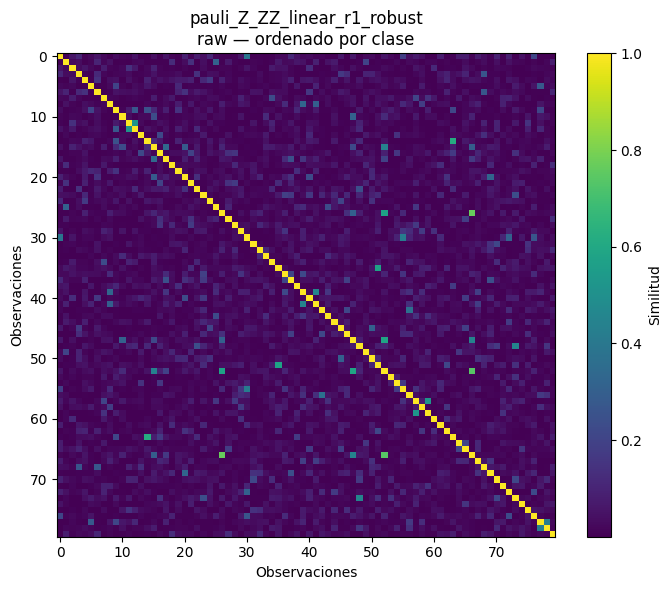

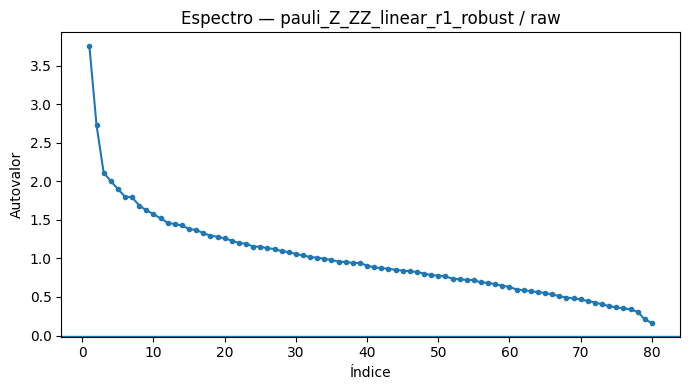

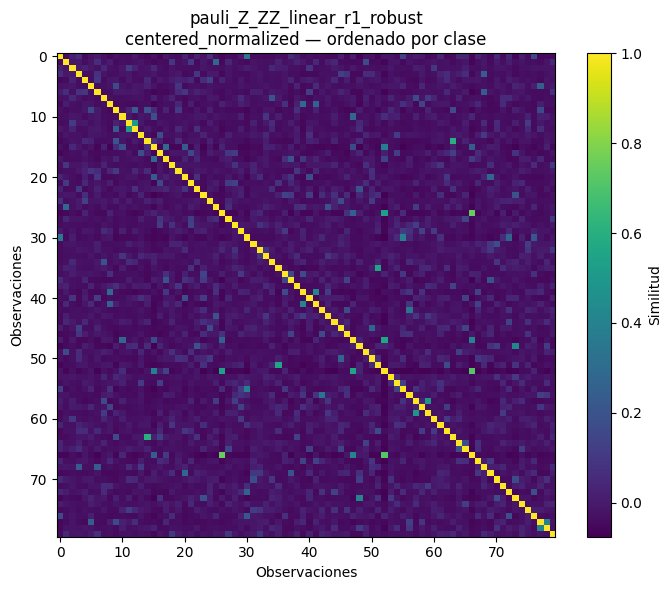

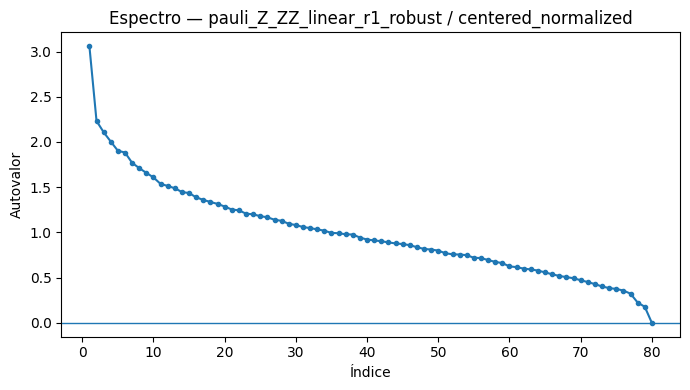

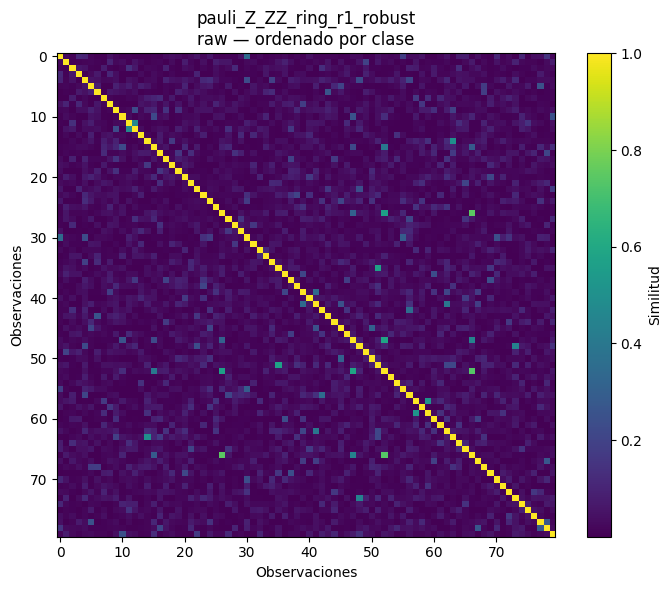

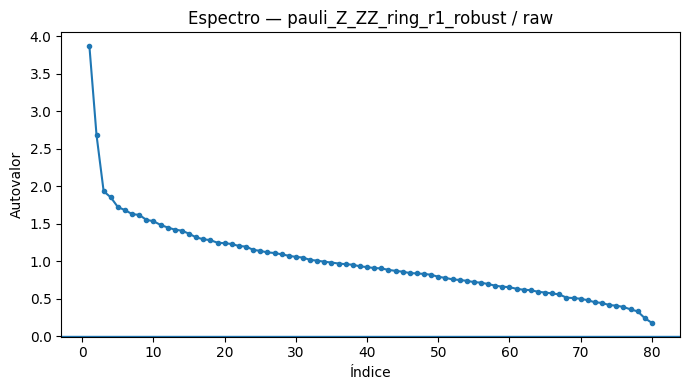

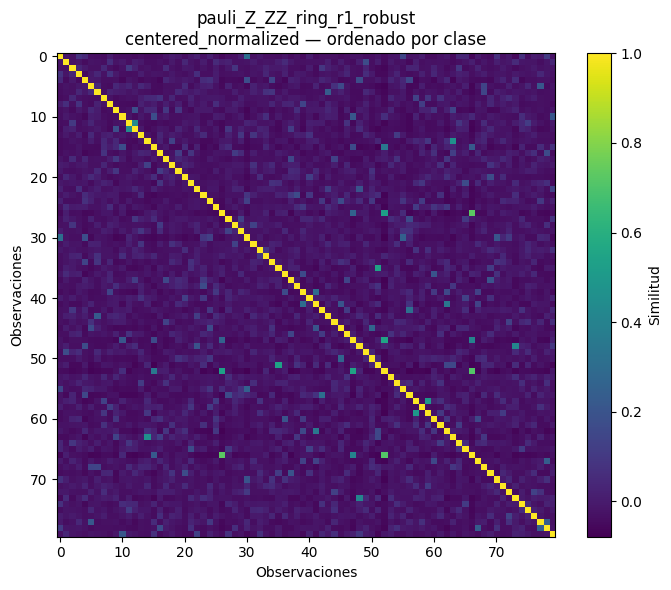

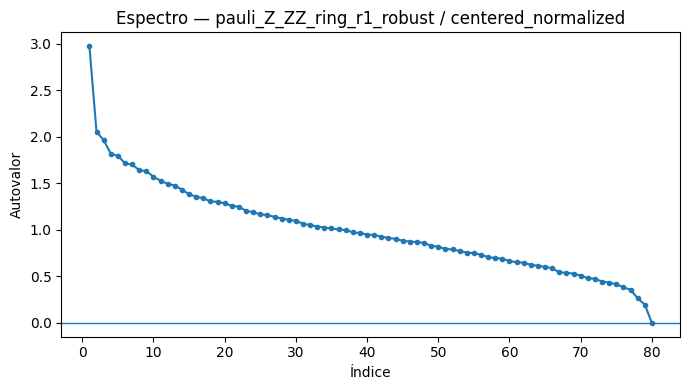

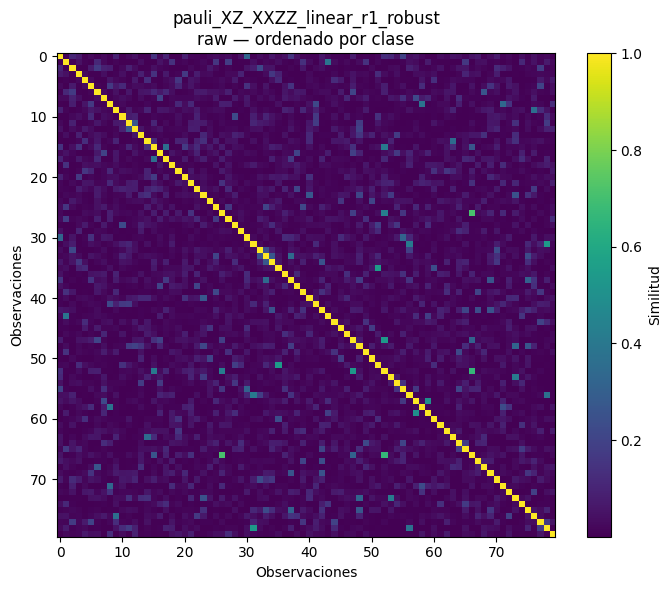

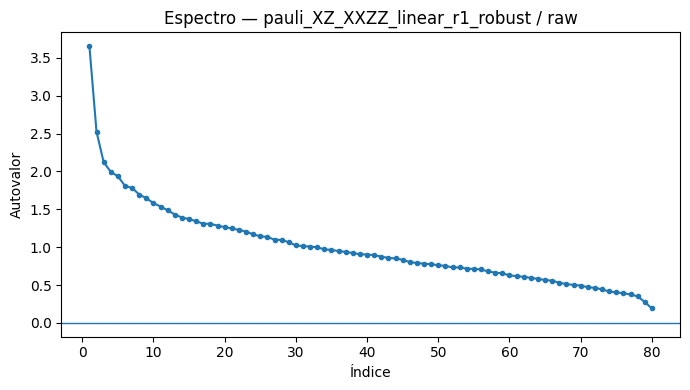

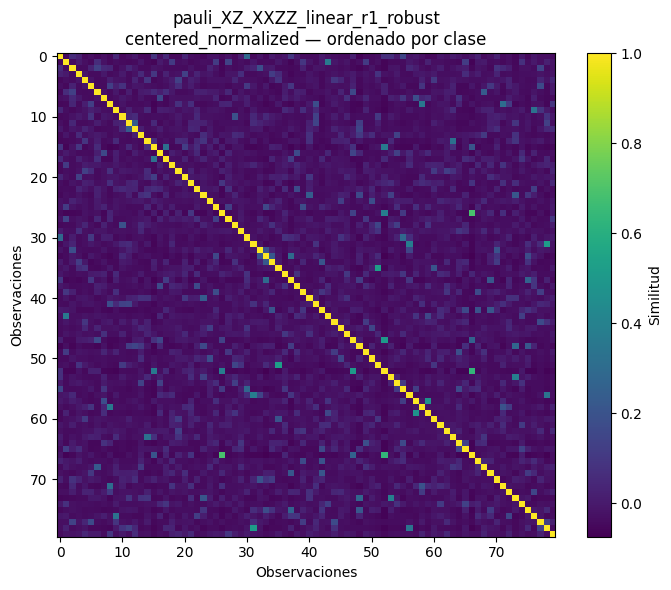

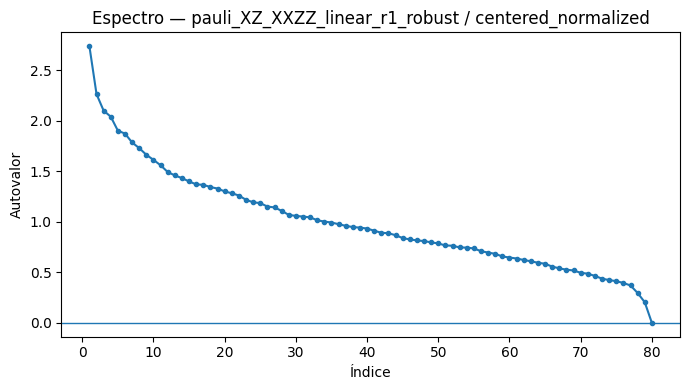

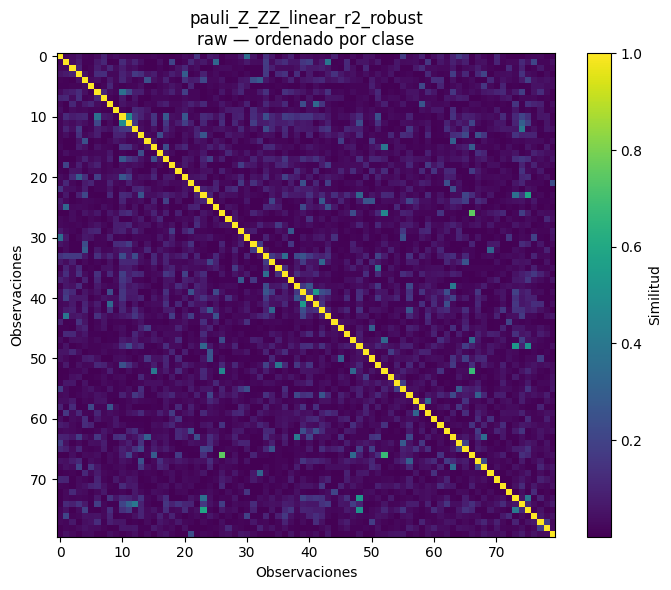

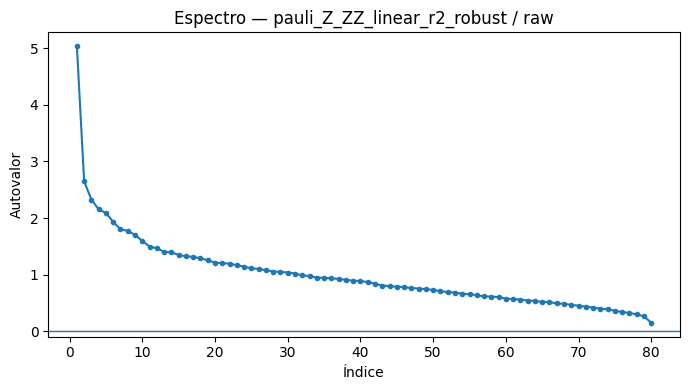

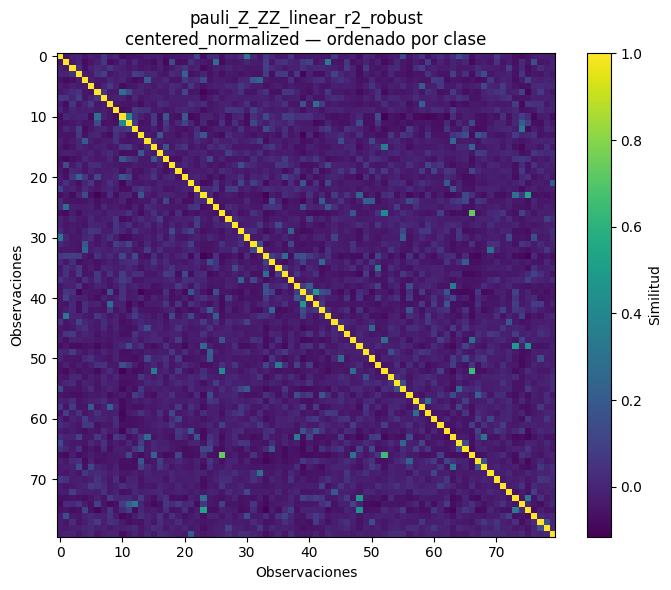

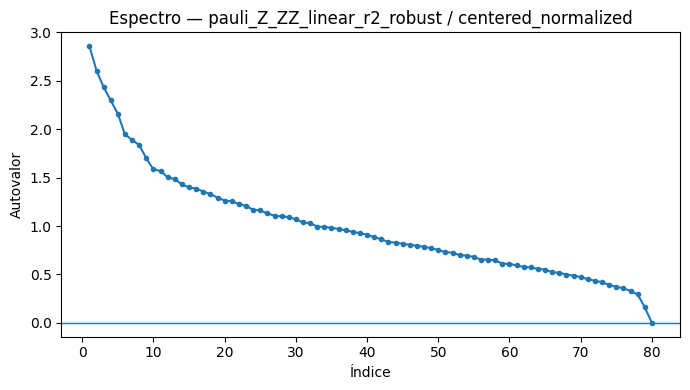

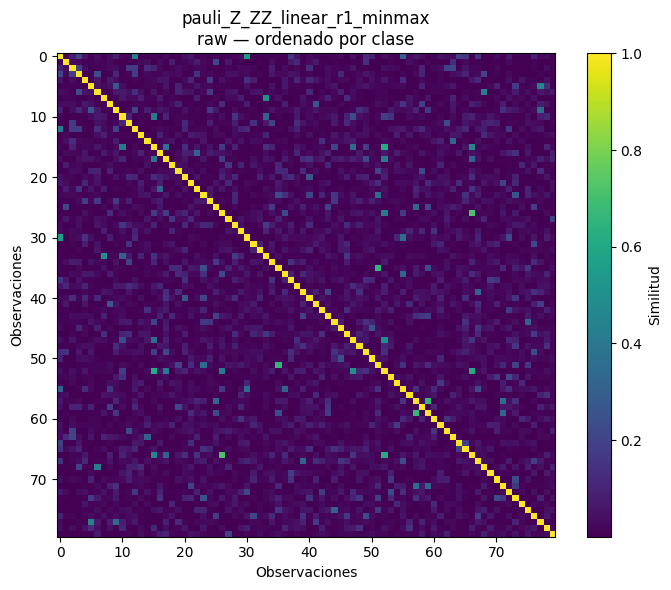

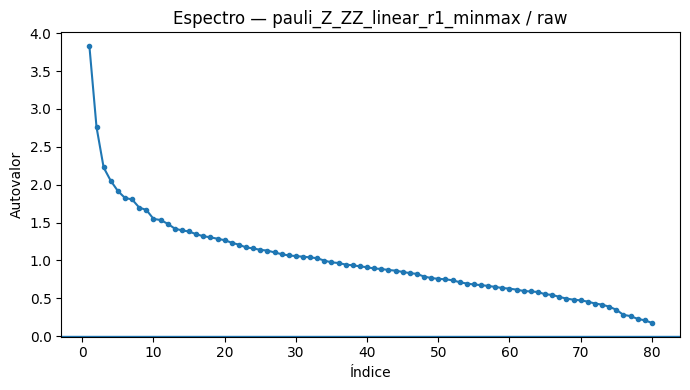

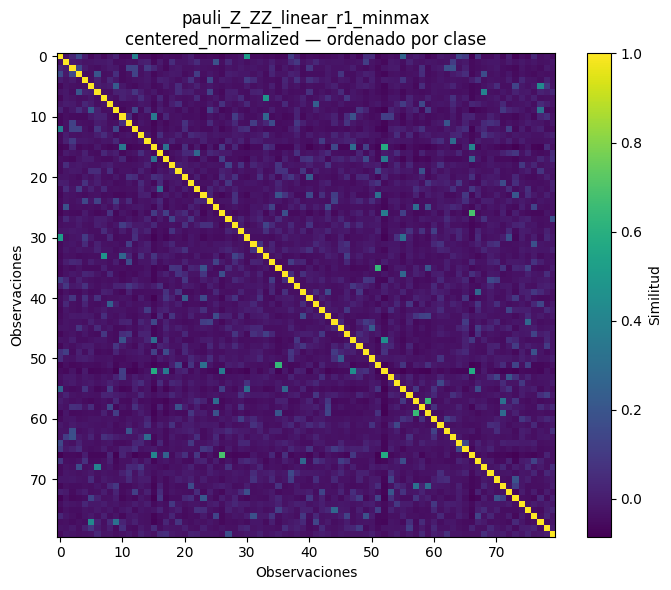

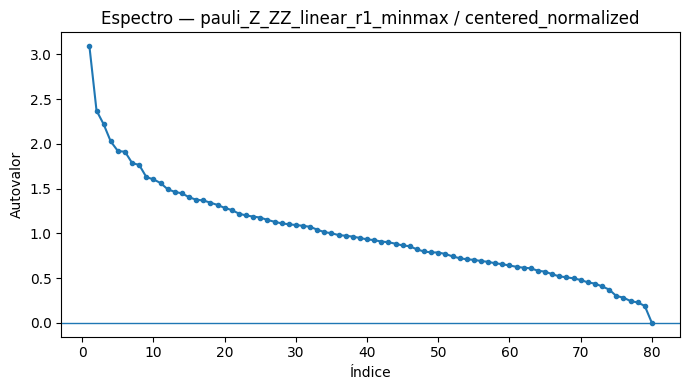

,map,kernel_mode,seconds,alignment,intra_mean,inter_mean,intra_minus_inter,effective_rank,min_eigenvalue,max_eigenvalue
7,pauli_Z_ZZ_linear_r2_robust,centered_normalized,0.190823,0.111705,-0.010979,-0.014284,0.003305,69.060181,-1.452424e-15,2.857793
1,pauli_Z_ZZ_linear_r1_robust,centered_normalized,0.092830,0.104046,-0.012193,-0.013109,0.000916,70.043287,8.999420e-16,3.058956
3,pauli_Z_ZZ_ring_r1_robust,centered_normalized,0.117621,0.101660,-0.012710,-0.012605,-0.000105,71.317631,-5.346374e-16,2.973394
6,pauli_Z_ZZ_linear_r2_robust,raw,0.190823,0.099714,0.047466,0.044400,0.003067,67.172278,1.493271e-01,5.033480
9,pauli_Z_ZZ_linear_r1_minmax,centered_normalized,0.103442,0.099390,-0.012719,-0.012595,-0.000124,69.584492,1.496820e-15,3.090710
0,pauli_Z_ZZ_linear_r1_robust,raw,0.092830,0.097579,0.032857,0.031961,0.000896,69.517725,1.639953e-01,3.753657
5,pauli_XZ_XXZZ_linear_r1_robust,centered_normalized,0.217040,0.096299,-0.013302,-0.012029,-0.001273,70.747798,3.658637e-16,2.736144
2,pauli_Z_ZZ_ring_r1_robust,raw,0.117621,0.094606,0.034216,0.034303,-0.000087,70.568195,1.810925e-01,3.866413
8,pauli_Z_ZZ_linear_r1_minmax,raw,0.103442,0.093254,0.032635,0.032710,-0.000075,69.051477,1.754210e-01,3.828432
4,pauli_XZ_XXZZ_linear_r1_robust,raw,0.217040,0.090199,0.031486,0.032709,-0.001224,70.210215,1.900509e-01,3.654750


In [16]:
geometry_rows = []
global_kernels = {}
y_quantum = quantum_df[TARGET].to_numpy(dtype=int)

for config in MAPS:
    imputer, scaler, angles = fit_quantum_preprocessor(
        quantum_df[SELECTED_FEATURES], config.scaling
    )
    t0 = time.perf_counter()
    states = statevectors_from_angles(angles, config)
    K_raw = fidelity_kernel(states)
    elapsed = time.perf_counter() - t0

    for mode in KERNEL_MODES:
        K = transform_square_kernel(K_raw, mode)
        global_kernels[f"{config.name}__{mode}"] = K
        geometry_rows.append({
            "map": config.name,
            "kernel_mode": mode,
            "seconds": elapsed,
            **kernel_geometry(K, y_quantum),
        })

        order = np.argsort(y_quantum, kind="stable")
        fig, ax = plt.subplots(figsize=(7, 6))
        image = ax.imshow(K[np.ix_(order, order)], aspect="auto")
        ax.set_title(f"{config.name}\n{mode} — ordenado por clase")
        ax.set_xlabel("Observaciones")
        ax.set_ylabel("Observaciones")
        fig.colorbar(image, ax=ax, label="Similitud")
        fig.tight_layout()
        fig.savefig(
            ARTIFACT_DIR / f"heatmap_{config.name}_{mode}.png",
            dpi=180,
            bbox_inches="tight",
        )
        plt.show()

        eig = np.linalg.eigvalsh((K + K.T) / 2)[::-1]
        fig, ax = plt.subplots(figsize=(7, 4))
        ax.plot(np.arange(1, len(eig) + 1), eig, marker=".")
        ax.set_title(f"Espectro — {config.name} / {mode}")
        ax.set_xlabel("Índice")
        ax.set_ylabel("Autovalor")
        ax.axhline(0, linewidth=1)
        fig.tight_layout()
        fig.savefig(
            ARTIFACT_DIR / f"spectrum_{config.name}_{mode}.png",
            dpi=180,
            bbox_inches="tight",
        )
        plt.show()

geometry_df = pd.DataFrame(geometry_rows).sort_values(
    ["alignment", "intra_minus_inter"], ascending=False
)
save_csv(geometry_df, "pauli_kernel_geometry.csv")
np.savez_compressed(
    ARTIFACT_DIR / "pauli_global_kernels.npz",
    **global_kernels,
)
display(geometry_df)


## 11. Recursos del circuito después de descomponer las cajas

Contar una `PauliExpBox` como una sola operación escondería su costo. Por eso se aplica
`DecomposeBoxes` antes de medir profundidad y compuertas de dos qubits.


In [17]:
resource_rows = []
for config in MAPS:
    boxed = build_pauli_feature_map(
        np.full(N_QUBITS, np.pi / 2), config
    )
    decomposed = boxed.copy()
    DecomposeBoxes().apply(decomposed)

    qasm_path = ARTIFACT_DIR / f"circuit_{config.name}.qasm"
    qasm_path.write_text(circuit_to_qasm_str(decomposed), encoding="utf-8")

    html_path = ARTIFACT_DIR / f"circuit_{config.name}_boxed.html"
    html_path.write_text(render_circuit_as_html(boxed), encoding="utf-8")

    resource_rows.append({
        **asdict(config),
        "n_qubits": N_QUBITS,
        "statevector_dimension": 2 ** N_QUBITS,
        "depth_decomposed": decomposed.depth(),
        "two_qubit_depth_decomposed": decomposed.depth_2q(),
        "cx_count_decomposed": decomposed.n_gates_of_type(OpType.CX),
        "two_qubit_gate_count_decomposed": decomposed.n_2qb_gates(),
        "total_gate_count_decomposed": decomposed.n_gates,
    })

resource_df = pd.DataFrame(resource_rows)
save_csv(resource_df, "pauli_circuit_resources.csv")
display(resource_df)


,name,local_terms,pair_terms,reps,topology,scaling,alpha,n_qubits,statevector_dimension,depth_decomposed,two_qubit_depth_decomposed,cx_count_decomposed,two_qubit_gate_count_decomposed,total_gate_count_decomposed
0,pauli_Z_ZZ_linear_r1_robust,"(Z,)","(ZZ,)",1,linear,robust_atan,1.0,5,32,14,8,8,8,22
1,pauli_Z_ZZ_ring_r1_robust,"(Z,)","(ZZ,)",1,ring,robust_atan,1.0,5,32,17,10,10,10,25
2,pauli_XZ_XXZZ_linear_r1_robust,"(X, Z)","(XX, ZZ)",1,linear,robust_atan,1.0,5,32,31,12,16,16,65
3,pauli_Z_ZZ_linear_r2_robust,"(Z,)","(ZZ,)",2,linear,robust_atan,1.0,5,32,22,12,16,16,44
4,pauli_Z_ZZ_linear_r1_minmax,"(Z,)","(ZZ,)",1,linear,minmax,1.0,5,32,14,8,8,8,22


## 12. Selección final y evaluación única en el holdout bloqueado

La combinación se elige por F1 medio; los desempates usan exactitud balanceada y MCC.
Después se reajusta `C` únicamente con las 80 filas de entrenamiento y se abre el holdout.


In [18]:
quantum_summary = summary_metrics[summary_metrics["model"] == "quantum"].copy()
best_quantum = quantum_summary.sort_values(
    ["f1_mean", "balanced_accuracy_mean", "mcc_mean"],
    ascending=False,
).iloc[0]

BEST_MAP_NAME = best_quantum["map"]
BEST_KERNEL_MODE = best_quantum["kernel_mode"]
BEST_CONFIG = next(m for m in MAPS if m.name == BEST_MAP_NAME)

X_quantum = quantum_df[SELECTED_FEATURES].reset_index(drop=True)
y_quantum = quantum_df[TARGET].to_numpy(dtype=int)
X_holdout = df.iloc[holdout_idx][SELECTED_FEATURES].reset_index(drop=True)
y_holdout = df.iloc[holdout_idx][TARGET].to_numpy(dtype=int)

best_C, full_inner_details = inner_select_quantum_c(
    X_quantum,
    y_quantum,
    BEST_CONFIG,
    BEST_KERNEL_MODE,
    SEED_INNER_FOLDS + 9999,
)

imputer, scaler, train_angles = fit_quantum_preprocessor(
    X_quantum, BEST_CONFIG.scaling
)
holdout_angles = scaler.transform(imputer.transform(X_holdout))

S_train = statevectors_from_angles(train_angles, BEST_CONFIG)
S_holdout = statevectors_from_angles(holdout_angles, BEST_CONFIG)
K_train_raw = fidelity_kernel(S_train)
K_holdout_raw = fidelity_kernel(S_holdout, S_train)
K_train, K_holdout = transform_train_cross_kernel(
    K_train_raw, K_holdout_raw, BEST_KERNEL_MODE
)

final_qsvc = SVC(
    kernel="precomputed",
    C=best_C,
    class_weight="balanced",
)
final_qsvc.fit(K_train, y_quantum)
q_pred = final_qsvc.predict(K_holdout)
q_decision = final_qsvc.decision_function(K_holdout)
q_metrics = classification_metrics(y_holdout, q_pred)

# Baseline clásico en las mismas 80 filas y el mismo holdout.
classical_candidates = []
inner = StratifiedKFold(
    n_splits=N_INNER_FOLDS,
    shuffle=True,
    random_state=SEED_INNER_FOLDS + 9999,
)
for C in C_GRID:
    for gamma in ["scale", 0.1, 1.0]:
        scores = []
        for tr, va in inner.split(X_quantum, y_quantum):
            pipe = Pipeline([
                ("imputer", SimpleImputer(strategy="median")),
                ("scaler", StandardScaler()),
                ("svc", SVC(
                    kernel="rbf", C=C, gamma=gamma,
                    class_weight="balanced",
                )),
            ])
            pipe.fit(X_quantum.iloc[tr], y_quantum[tr])
            p = pipe.predict(X_quantum.iloc[va])
            scores.append(f1_score(y_quantum[va], p, zero_division=0))
        classical_candidates.append((np.mean(scores), np.std(scores), C, gamma))

_, _, classical_C, classical_gamma = sorted(
    classical_candidates,
    key=lambda z: (-z[0], z[1], z[2], str(z[3])),
)[0]

final_classical = Pipeline([
    ("imputer", SimpleImputer(strategy="median")),
    ("scaler", StandardScaler()),
    ("svc", SVC(
        kernel="rbf",
        C=classical_C,
        gamma=classical_gamma,
        class_weight="balanced",
    )),
])
final_classical.fit(X_quantum, y_quantum)
c_pred = final_classical.predict(X_holdout)
c_decision = final_classical.decision_function(X_holdout)
c_metrics = classification_metrics(y_holdout, c_pred)

holdout_metrics = pd.DataFrame([
    {
        "model": "pytket_pauli_kernel",
        "map": BEST_MAP_NAME,
        "kernel_mode": BEST_KERNEL_MODE,
        "C": best_C,
        "gamma": np.nan,
        **q_metrics,
    },
    {
        "model": "classical_rbf_same_80",
        "map": "classical_rbf",
        "kernel_mode": "rbf",
        "C": classical_C,
        "gamma": classical_gamma,
        **c_metrics,
    },
])

holdout_predictions = pd.concat([
    pd.DataFrame({
        "model": "pytket_pauli_kernel",
        "source_index": df.iloc[holdout_idx]["source_index"].to_numpy(),
        "y_true": y_holdout,
        "y_pred": q_pred,
        "decision": q_decision,
    }),
    pd.DataFrame({
        "model": "classical_rbf_same_80",
        "source_index": df.iloc[holdout_idx]["source_index"].to_numpy(),
        "y_true": y_holdout,
        "y_pred": c_pred,
        "decision": c_decision,
    }),
], ignore_index=True)

save_csv(holdout_metrics, "FINAL_LOCKED_HOLDOUT_METRICS.csv")
save_csv(holdout_predictions, "FINAL_LOCKED_HOLDOUT_PREDICTIONS.csv")
write_json(
    ARTIFACT_DIR / "selected_pauli_configuration.json",
    {
        "selected_before_holdout": True,
        "map": BEST_MAP_NAME,
        "kernel_mode": BEST_KERNEL_MODE,
        "C": best_C,
        "cv_metrics": best_quantum.to_dict(),
        "config": asdict(BEST_CONFIG),
    },
)
display(holdout_metrics)


,model,map,kernel_mode,C,gamma,accuracy,balanced_accuracy,precision,recall,specificity,f1,mcc,tn,fp,fn,tp
0,pytket_pauli_kernel,pauli_Z_ZZ_ring_r1_robust,centered_normalized,10.0,NaN,0.542683,0.528672,0.421986,0.464844,0.5925,0.442379,0.056504,237,163,137,119
1,classical_rbf_same_80,classical_rbf,rbf,10.0,scale,0.533537,0.555625,0.435233,0.656250,0.4550,0.523364,0.110274,182,218,88,168


## 13. Sensibilidad a shots y reparación PSD

Esta sección es un diagnóstico estadístico sobre el kernel global del mapa seleccionado.
La estimación binomial independiente puede producir matrices indefinidas. Se reportan tanto
la matriz cruda como una proyección PSD con normalización diagonal.

Estos resultados **no sustituyen** la validación cruzada exacta.


In [19]:
def simulate_shot_kernel(
    K: np.ndarray,
    shots: int,
    rng: np.random.Generator,
) -> np.ndarray:
    n = len(K)
    sampled = np.eye(n)
    for i in range(n):
        for j in range(i + 1, n):
            value = rng.binomial(shots, np.clip(K[i, j], 0, 1)) / shots
            sampled[i, j] = sampled[j, i] = value
    return sampled


def project_psd_correlation(K: np.ndarray, eps: float = 1e-10) -> np.ndarray:
    K = (np.asarray(K) + np.asarray(K).T) / 2
    eigvals, eigvecs = np.linalg.eigh(K)
    eigvals = np.clip(eigvals, eps, None)
    repaired = (eigvecs * eigvals) @ eigvecs.T
    diagonal = np.sqrt(np.clip(np.diag(repaired), eps, None))
    repaired = repaired / np.outer(diagonal, diagonal)
    return (repaired + repaired.T) / 2


selected_global_raw = global_kernels[f"{BEST_MAP_NAME}__raw"]
shot_rows = []

for shots in [256, 1024, 4096]:
    for repeat in range(10):
        rng = np.random.default_rng(SEED_SHOTS + shots + repeat)
        noisy = simulate_shot_kernel(selected_global_raw, shots, rng)
        repaired = project_psd_correlation(noisy)

        for version, matrix in [("raw_sampled", noisy), ("psd_repaired", repaired)]:
            eig = np.linalg.eigvalsh((matrix + matrix.T) / 2)
            shot_rows.append({
                "shots": shots,
                "repeat": repeat,
                "version": version,
                "mae_vs_exact": float(np.mean(np.abs(matrix - selected_global_raw))),
                "min_eigenvalue": float(eig.min()),
                "alignment": kernel_alignment(matrix, y_quantum),
                "effective_rank": effective_rank(matrix),
            })

shot_df = pd.DataFrame(shot_rows)
shot_summary = (
    shot_df.groupby(["shots", "version"])
    .agg(
        mae_mean=("mae_vs_exact", "mean"),
        mae_std=("mae_vs_exact", "std"),
        min_eigenvalue_mean=("min_eigenvalue", "mean"),
        alignment_mean=("alignment", "mean"),
        effective_rank_mean=("effective_rank", "mean"),
    )
    .reset_index()
)
save_csv(shot_df, "pauli_shot_sensitivity.csv")
save_csv(shot_summary, "pauli_shot_sensitivity_summary.csv")
display(shot_summary)


,shots,version,mae_mean,mae_std,min_eigenvalue_mean,alignment_mean,effective_rank_mean
0,256,psd_repaired,0.007439,0.000092,0.159162,0.094741,70.133231
1,256,raw_sampled,0.007439,0.000092,0.159162,0.094741,70.133231
2,1024,psd_repaired,0.003746,0.000035,0.172752,0.094458,70.517748
3,1024,raw_sampled,0.003746,0.000035,0.172752,0.094458,70.517748
4,4096,psd_repaired,0.001861,0.000032,0.181228,0.094562,70.530001
5,4096,raw_sampled,0.001861,0.000032,0.181228,0.094562,70.530001


## 14. Comprobaciones y manifiesto final


In [20]:
checks = [
    ("only_dataset_as_external_input", True),
    ("dataset_snapshot_hash_matches", sha256_file(SNAPSHOT_PATH) == dataset_hash),
    ("all_primary_splits_disjoint", not (
        sets[0] & sets[1] or sets[0] & sets[2] or sets[1] & sets[2]
    )),
    ("feature_selection_independent_of_quantum_rows", True),
    ("feature_selection_independent_of_holdout", True),
    ("feature_count_matches_qubits", len(SELECTED_FEATURES) == N_QUBITS),
    ("quantum80_balanced", quantum_df[TARGET].value_counts().to_dict() == {0: 40, 1: 40}),
    ("five_folds_balanced_8_8", bool((fold_balance.to_numpy() == 8).all())),
    ("quantum80_has_no_holdout_rows", not bool(
        set(quantum_df["source_index"]) & set(df.iloc[holdout_idx]["source_index"])
    )),
    ("no_qiskit_imported", not any(name.startswith("qiskit") for name in sys.modules)),
    ("uses_pauliexpbox", True),
    ("holdout_evaluated_after_map_selection", True),
]
checks_df = pd.DataFrame(checks, columns=["check", "passed"])
assert checks_df["passed"].all()
save_csv(checks_df, "pytket_pauli_reproducibility_checks.csv")

# Verificar de nuevo todos los archivos congelados.
for rec in DATA_LOCK["locked_files"]:
    path = ARTIFACT_DIR / rec["file"]
    assert path.exists()
    assert sha256_file(path) == rec["sha256"]

all_artifacts = sorted(
    p for p in ARTIFACT_DIR.iterdir()
    if p.is_file() and p.name != "FINAL_MANIFEST.json"
)
manifest = {
    "project": "Water Potability — pytket Pauli feature map from scratch",
    "pytket_version": pytket.__version__,
    "python_version": sys.version,
    "dataset_sha256": dataset_hash,
    "run_config_sha256": DATA_LOCK["run_config_sha256"],
    "selected_features": SELECTED_FEATURES,
    "best_map": BEST_MAP_NAME,
    "best_kernel_mode": BEST_KERNEL_MODE,
    "holdout_is_final": True,
    "artifacts": [file_record(p) for p in all_artifacts],
}
write_json(ARTIFACT_DIR / "FINAL_MANIFEST.json", manifest)

display(checks_df)
print("Artefactos:", len(manifest["artifacts"]) + 1)
print("Carpeta:", ARTIFACT_DIR)


,check,passed
0,only_dataset_as_external_input,True
1,dataset_snapshot_hash_matches,True
2,all_primary_splits_disjoint,True
3,feature_selection_independent_of_quantum_rows,True
4,feature_selection_independent_of_holdout,True
5,feature_count_matches_qubits,True
6,quantum80_balanced,True
7,five_folds_balanced_8_8,True
8,quantum80_has_no_holdout_rows,True
9,no_qiskit_imported,True


Artefactos: 110
Carpeta: /content/drive/MyDrive/Colab Notebooks/artifacts_pytket_pauli_from_scratch_v1


## Lectura recomendada de los resultados

1. Use `pauli_cv_summary.csv` para comparar mapas y el baseline clásico en las mismas 80 filas.
2. Confirme que el mejor mapa no solo tenga F1 alto: revise MCC, desviación entre folds y geometría.
3. Un `intra_minus_inter` cercano a cero indica que el mapa no induce bloques útiles, aunque algún fold tenga buen F1.
4. Prefiera una capa y topología lineal cuando el rendimiento sea similar: reduce profundidad y compuertas de dos qubits.
5. La evaluación en `FINAL_LOCKED_HOLDOUT_METRICS.csv` es final; no debe usarse para seguir ajustando el mapa.
6. Para hardware real, use las matrices PSD reparadas como diagnóstico y añada compilación dirigida a la arquitectura concreta.
